# GalaxyMNIST S4 Model Training, Evaluation, and Weight Export (PyTorch Version)

## About GalaxyMNIST

GalaxyMNIST is a dataset of galaxy morphology images designed as an astronomy-specific alternative to traditional benchmark datasets like MNIST. Created by Mike Walmsley and colleagues, it contains 10,000 galaxies from the Galaxy Zoo project, each labeled as one of four morphological types:

- **Smooth Round**: Elliptical galaxies with smooth, featureless light distributions
- **Smooth Cigar**: Elongated elliptical galaxies viewed edge-on
- **Edge-on Disk**: Spiral galaxies viewed edge-on, showing a thin disk structure
- **Unbarred Spiral**: Face-on spiral galaxies with visible spiral arm patterns

Each image is 64×64 pixels with 3 color channels (RGB), derived from SDSS imaging data. The dataset presents a more challenging and scientifically relevant classification task compared to handwritten digits, with real-world astronomical noise, varying brightness scales, and subtle morphological differences.

**References:**
- Walmsley, M., et al. (2022). "Galaxy Zoo DECaLS: Detailed visual morphology measurements from volunteers and deep learning for 314,000 galaxies." *Monthly Notices of the Royal Astronomical Society*, 509(3), 3966-3988.
- GalaxyMNIST Repository: https://github.com/mwalmsley/galaxy_mnist

---

**This notebook** demonstrates training a Structured State Space (S4) model for galaxy morphology classification. We convert RGB images to grayscale, flatten them using a Hilbert curve to preserve spatial locality, and process them as 1D sequences of 4,096 pixels. The S4 architecture's ability to capture long-range dependencies makes it well-suited for this task, achieving competitive performance without traditional convolutional layers.

## Preliminary Setup

Note: Python version 3.11.7 is used in this notebook.

In [3]:
# Check if GPU is available
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [40]:
# If you have a GPU, prefer installing the CUDA version of PyTorch
# Refer to https://pytorch.org/get-started/locally/ for specific instructions.
# For example for CUDA 13.0, you can use the following command:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cu130

# For CPU-only installation, you can use the following command:
# %pip install torch torchvision

# Other dependencies
%pip install numpy matplotlib scikit-learn h5py tqdm seaborn torchinfo einops

Looking in indexes: https://download.pytorch.org/whl/cu130
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [41]:
# Install GalaxyMNIST from source
# The specific commit used is: https://github.com/mwalmsley/galaxy_mnist/tree/c1fe9853a00bc34b2ff082585c6bb1654d34d239
%pip install git+https://github.com/mwalmsley/galaxy_mnist.git@c1fe9853a00bc34b2ff082585c6bb1654d34d239

  Cloning https://github.com/mwalmsley/galaxy_mnist.git (to revision c1fe9853a00bc34b2ff082585c6bb1654d34d239) to /tmp/pip-req-build-vwly2mu9
  Running command git clone --filter=blob:none --quiet https://github.com/mwalmsley/galaxy_mnist.git /tmp/pip-req-build-vwly2mu9
  Running command git rev-parse -q --verify 'sha^c1fe9853a00bc34b2ff082585c6bb1654d34d239'
  Running command git fetch -q https://github.com/mwalmsley/galaxy_mnist.git c1fe9853a00bc34b2ff082585c6bb1654d34d239
  Running command git checkout -q c1fe9853a00bc34b2ff082585c6bb1654d34d239
  Resolved https://github.com/mwalmsley/galaxy_mnist.git to commit c1fe9853a00bc34b2ff082585c6bb1654d34d239
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.


## 1. Imports and Configurations

In [44]:
# Standard library
import csv
import random

# Numerical / plotting
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from tqdm import tqdm   #befroe it was from tqdm.notebook import tqd

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary

# Classifier
from model import GalaxyClassifierS4D
from model.functions import export_model_parameters, load_data

from utils import set_pbar_style

In [45]:
set_pbar_style(bar_fill_color="#FFFFFF", text_color="#FFFFFF") # Make progress bars look good in notebooks
DEVICE = "cuda" if torch.cuda.is_available() else "cpu" # Set device

CLASS_NAMES =  ["Smooth Round", "Smooth Cigar", "Edge-on Disk", "Unbarred Spiral"] # Class names for GalaxyMNIST

# Whether to use colored images
COLORED = False  # Start with grayscale

# Set RNG seeds for reproducibility
# Use your ERP id...
RNG_SEED = 30609 # TODO: Replace with your ERP id for actual experiments

# Set seeds
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)
torch.manual_seed(RNG_SEED)
if DEVICE == "cuda":
    torch.cuda.manual_seed_all(RNG_SEED)

print(f"Using RNG seed: {RNG_SEED}")
print(f"Using device: {DEVICE}")

Using RNG seed: 30609
Using device: cpu


In [46]:
# Visualization inside the jupyter
%matplotlib inline

# Load the "autoreload" extension so that code can change
%load_ext autoreload

# ----------
# Plot
# ----------
# graph style
sns.set_style("darkgrid")
plt.style.use('fivethirtyeight')

# ----------
# Seaborn rcParams
# ----------
rc={'savefig.dpi': 500, 
    'figure.autolayout': True, 
    'figure.figsize': [17, 12], 
    'axes.labelsize': 18,
    'axes.titlesize': 18, 
    'font.size': 10, 
    'lines.linewidth': 1.0, 
    'lines.markersize': 8, 
    'legend.fontsize': 15,
    'xtick.labelsize': 10, 
    'ytick.labelsize': 10}

sns.set_theme(context='notebook',  # notebook
        style='darkgrid',
        palette='deep',
        color_codes=True, 
        rc=rc)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 2. Load and Preprocess the GalaxyMNIST Dataset

We load the GalaxyMNIST dataset and preprocess it by converting RGB images to grayscale (averaging across channels) and normalizing pixel values to the [0, 1] range. The labels are converted to one-hot encoding for compatibility with the cross-entropy loss function.

In [47]:
X, y_onehot, y = load_data(root="./data", download=True, train=True, colored=COLORED)
NUM_CLASSES = y_onehot.shape[1]

Original Dataset Size: 8000 samples


In [48]:
# Verify the new dataset size
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"y_onehot shape: {y_onehot.shape}")
print(f"Number of classes: {NUM_CLASSES}")

X shape: torch.Size([8000, 1, 64, 64])
y shape: torch.Size([8000])
y_onehot shape: torch.Size([8000, 4])
Number of classes: 4


### 2.2 Prepare the Test and Train Datasets

We split the dataset into training (80%) and validation (20%) sets using stratified sampling to maintain class balance. PyTorch DataLoaders are created with a batch size of 64 for efficient mini-batch training.

In [49]:
BATCH_SIZE = 64

# Split into train/validation sets
x_train, x_val, y_train_onehot, y_val_onehot = train_test_split(X, y_onehot, test_size=0.2, random_state=RNG_SEED, stratify=y)

# Create TensorDatasets
train_ds = TensorDataset(x_train, y_train_onehot)
val_ds = TensorDataset(x_val, y_val_onehot)

# Create DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE)

### 2.3 Save Sample Images for Later Use in C/RISC-V Programs

We export 100 random training samples to a CSV file for testing inference implementations in lower-level languages. Each row contains the true label followed by the flattened 4,096 pixel values.

In [50]:
# This currently makes a CSV dump. 
# For RISCV programs, it would be better to store it in assembly format
# i.e.
#
# .data
# sample: 
#   .float 0.0, 1.0, 2.0, ...
#   .float ...
#
# TODO: Update this to dump in assembly format if specified

indices = random.sample(range(len(x_train)), 100)

with open("galaxy_samples.csv", "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    for idx in indices:
        image = x_train[idx].squeeze().numpy()  # (64, 64)
        label = torch.argmax(y_train_onehot[idx]).item()
        row = [label] + image.flatten().tolist()
        writer.writerow(row)

## 3. Visualize GalaxyMNIST Images

### 3.1 Define a Function to Display Images

In [51]:
def plot_galaxy_images(x_data, y_data, num_images=16, colored=False):
    """
    Function to plot a grid of random GalaxyMNIST images with labels.

    Parameters:
    x_data (torch.Tensor): Input images (N,1,64,64)
    y_data (torch.Tensor): Labels (N,) as integer class indices
    num_images (int): Number of images to display
    colored (bool): Whether to plot in color or grayscale
    """
    random_indices = np.random.choice(len(x_data), num_images, replace=False)
    random_images = x_data[random_indices].squeeze().numpy()  # remove channel dim
    random_labels = torch.argmax(y_data[random_indices], dim=1).numpy()

    if num_images == 3:
        rows = 1
        cols = 3
    else:
        cols = int(np.ceil(np.sqrt(num_images)))
        rows = int(np.ceil(num_images / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))

    if not isinstance(axes, np.ndarray):
        axes = np.array([axes])
    axes = axes.flatten()

    for i in range(num_images):
        if colored:
            # x_data shape for RGB: (N, 3, H, W) → convert to HWC for imshow
            img = random_images[i]
            if img.ndim == 3:  # (C, H, W)
                img = np.transpose(img, (1, 2, 0))
            axes[i].imshow(img)
        else:
            # grayscale: 2D image
            sns.heatmap(random_images[i], ax=axes[i], cmap='magma', cbar=False, xticklabels=False, yticklabels=False)

        axes[i].set_title(CLASS_NAMES[random_labels[i]], fontsize=10)
        axes[i].axis('off')
        
    for j in range(num_images, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


### 3.2 Plot Galaxy Samples

Visualize a random selection of galaxy images from the dataset using the Magma colormap, which provides good contrast for astronomical data.

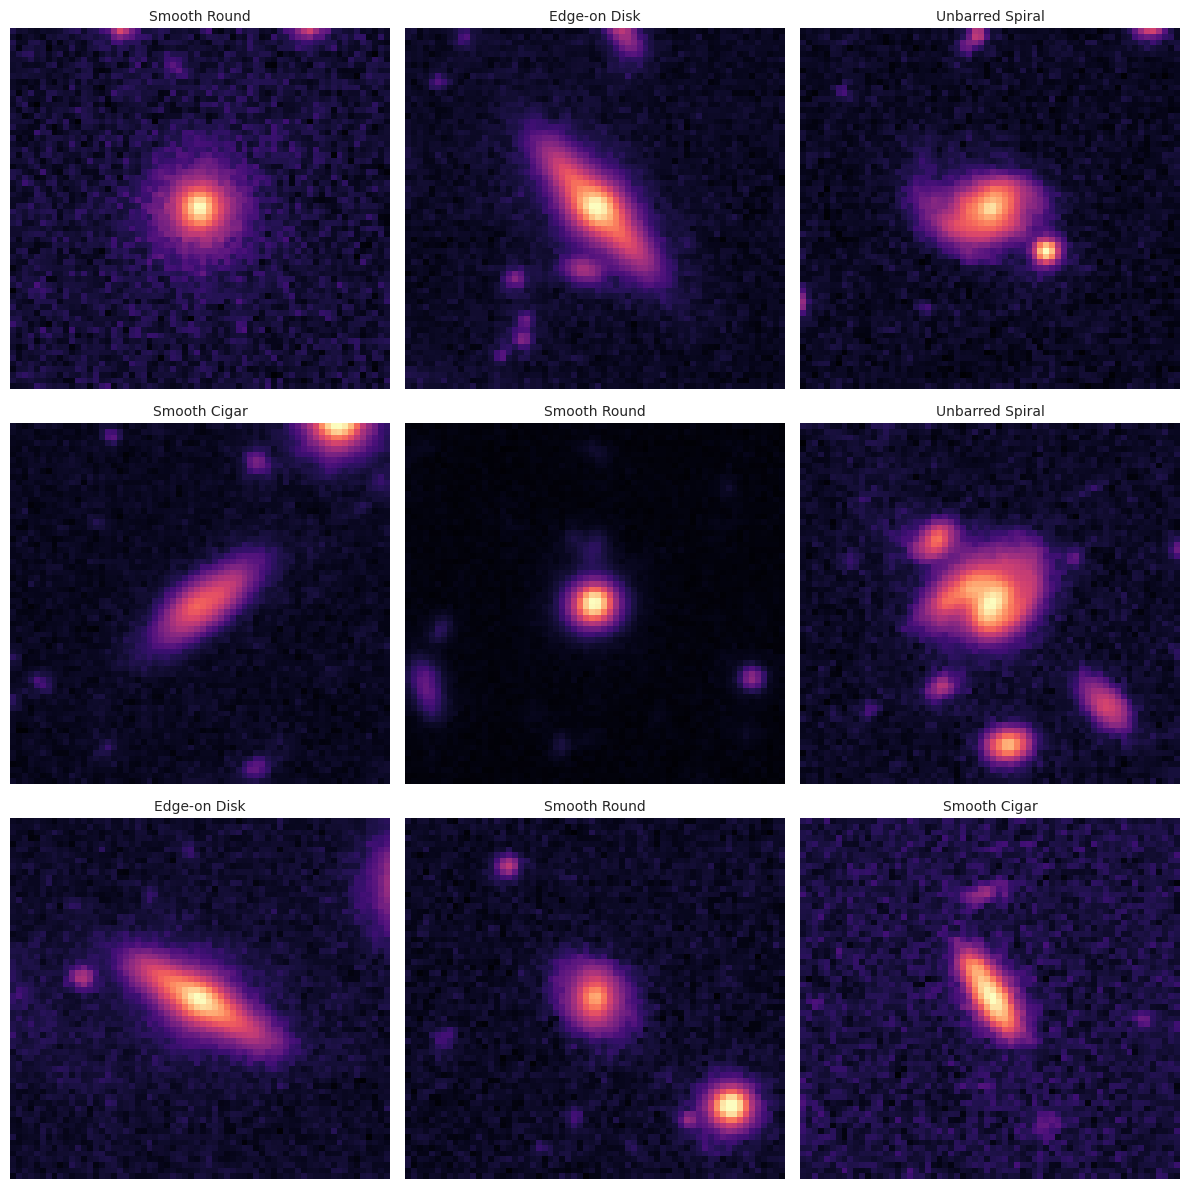

In [12]:
plot_galaxy_images(X, y_onehot, num_images=9, colored=COLORED)

## 4. Build the Structured State Space (S4) Model with Hilbert Curve Scanning

### 4.1 Hilbert Curve Preprocessing

Traditional sequence models process images in row-major order (left-to-right, top-to-bottom), which can disrupt spatial locality—pixels that are spatially close may be far apart in the sequence. The Hilbert curve is a space-filling curve that maps 2D coordinates to 1D while preserving locality: nearby pixels in 2D space remain nearby in the 1D sequence.

For our 64×64 galaxy images, we precompute the Hilbert curve traversal order and store it as a lookup table. This reordering helps the S4 model capture spatial relationships more effectively than naive flattening would.
    
### 4.2 S4 Model Architecture

Our model treats galaxy classification as a sequence modeling problem with the following architecture:

**Input Processing:**
- Input: 64×64 RGB or grayscale galaxy images → $(B, C, 64, 64)$ where $C = 3$ for RGB or $C = 1$ for grayscale
- Hilbert curve scanning → Reordered sequence $(B, 4096, C)$
- Input Projection: Linear layer mapping $C$-dimensional pixel values to model dimension $(B, 4096, d_{model})$

**S4 Sequence Processing:**
We stack two S4D (diagonal state space) layers, each with:
- State dimension: $d_{state} = 64$ (controls the model's memory capacity)
- Model dimension: $d_{model} = 64$ (output feature dimension)
- Activation: GELU after each S4 layer

The S4 layers model the sequential dependencies across the 4,096-pixel sequence, learning to identify morphological patterns that distinguish galaxy types.

**Classification Head:**
- Extract final timestep: Take the last hidden state $(B, 64)$ as the sequence summary
- Fully connected layer: Map to 4 class logits $(B, 4)$
- Softmax layer: Convert logits to probability distribution over classes

**Mathematical Flow:**

$$X_{img} \in \mathbb{R}^{C \times 64 \times 64} \xrightarrow{\text{Hilbert}} X_{seq} \in \mathbb{R}^{4096 \times C}$$

$$X_{seq} \xrightarrow{\text{Linear}} X_{proj} \in \mathbb{R}^{4096 \times 64}$$

$$X_{proj} \xrightarrow{\text{S4D}_1} Z_1 \in \mathbb{R}^{4096 \times 64} \xrightarrow{\text{GELU}} A_1$$

$$A_1 \xrightarrow{\text{S4D}_2} Z_2 \in \mathbb{R}^{4096 \times 64} \xrightarrow{\text{GELU}} A_2$$

$$A_2[:, -1, :] \in \mathbb{R}^{64} \xrightarrow{\text{Linear}} Y_{logits} \in \mathbb{R}^{4} \xrightarrow{\text{Softmax}} Y_{probs}$$

In [52]:
# Instantiate model
model = GalaxyClassifierS4D(num_classes=NUM_CLASSES, colored=COLORED).to(DEVICE)
model_sum = summary(model, input_size=(2, 1 if not COLORED else 3, 64, 64)) # Summarize model
print(model_sum)

Layer (type:depth-idx)                   Output Shape              Param #
GalaxyClassifierS4D                      [2, 4]                    --
├─HilbertScan: 1-1                       [2, 4096, 1]              --
├─Linear: 1-2                            [2, 4096, 64]             128
├─S4D: 1-3                               [2, 4096, 64]             8,320
├─GELU: 1-4                              [2, 4096, 64]             --
├─S4D: 1-5                               [2, 4096, 64]             8,320
├─GELU: 1-6                              [2, 4096, 64]             --
├─TakeLastTimestep: 1-7                  [2, 64]                   --
├─Linear: 1-8                            [2, 4]                    260
├─Softmax: 1-9                           [2, 4]                    --
Total params: 17,028
Trainable params: 17,028
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.03
Forward/backward pass size (MB): 12.58
Params size (MB): 0.07
Estimated Total Size (M

In [53]:
import torch
import os

# 1. Path to your saved 'good' model
# The notebook you sent shows your seed is 30609
model_path = "model_params/galaxys4-30609.pth"

if os.path.exists(model_path):
    # 2. Load the saved weights from your disk
    # map_location ensures it works on CPU or GPU
    state_dict = torch.load(model_path, map_location=DEVICE)
    
    # 3. Put those weights back into your model
    model.load_state_dict(state_dict)
    model.to(DEVICE)
    
    # 4. Set to evaluation mode (this is huge for accuracy!)
    # It turns off dropout layers that would otherwise mess up test results
    model.eval()
    
    print(f" SUCCESS: Your good model ({model_path}) is now loaded!")
    print("Now go run the 'Test Accuracy' cell again. You'll see the real score.")
else:
    print(f" ERROR: Model file not found at {model_path}. Check your 'model_params' folder.")

 SUCCESS: Your good model (model_params/galaxys4-30609.pth) is now loaded!
Now go run the 'Test Accuracy' cell again. You'll see the real score.


In [58]:
import os
import datetime

print(f"{'File Name':<40} | {'Size (MB)':<10} | {'Last Modified'}")
print("-" * 80)

# Search for all .pth files in the current directory and subfolders
for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".pth"):
            full_path = os.path.join(root, file)
            stats = os.stat(full_path)
            size_mb = stats.st_size / (1024 * 1024)
            modified = datetime.datetime.fromtimestamp(stats.st_mtime)
            print(f"{full_path:<40} | {size_mb:<10.2f} | {modified}")

File Name                                | Size (MB)  | Last Modified
--------------------------------------------------------------------------------
./model_params/galaxys4-30609.pth        | 0.10       | 2026-02-13 20:25:32.997789


## 5. Compile and Train the Model

We train the model using the Adam optimizer with a learning rate of 0.001 and cross-entropy loss. 

In [54]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.0015)
loss_fn = nn.CrossEntropyLoss()

# Global training history
# Persistent across training runs
history = {
    "loss": [],
    "val_accuracy": []
}

In [55]:
def train(train_loader, val_loader, model, optimizer, loss_fn, epochs, device, verbose=True):
    """Train the model and validate after each epoch.

    Parameters:
    -----------
    train_loader : DataLoader
        DataLoader for training data.
    val_loader : DataLoader
        DataLoader for validation data.
    model : nn.Module
        The neural network model to train.
    optimizer : torch.optim.Optimizer
        Optimizer for updating model parameters.
    loss_fn : nn.Module
        Loss function to compute training loss.
    epochs : int
        Number of training epochs.
    device : torch.device
        Device to run the training on (CPU or GPU).

    Returns:
    --------
    history : dict
        Dictionary containing training loss and validation accuracy history.
    """

    history = {
        "loss": [],
        "val_accuracy": []
    }

    ebar = tqdm(range(epochs), desc="Training Progress", disable=verbose)

    # If verbose, don't show outer pbar
    for epoch in ebar:
        model.train()
        running_loss = 0.0

        # show pbar only if verbose
        pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} - Training", disable=not verbose)

        for inputs, targets in pbar:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs, return_logits=True)
            loss = loss_fn(outputs, torch.argmax(targets, dim=1))
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            pbar.set_postfix({"Batch Loss": loss.item()})

        epoch_loss = running_loss / len(train_loader)
        history["loss"].append(epoch_loss)

        # Validation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs, return_logits=True)

                predicted = torch.argmax(outputs, dim=1)
                target = torch.argmax(targets, dim=1)

                correct += (predicted == target).sum().item()
                total += targets.size(0)

        val_accuracy = correct / total
        history["val_accuracy"].append(val_accuracy)

        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f} - Val Accuracy: {val_accuracy:.4f}")

        ebar.set_postfix({"Loss": epoch_loss, "Val Acc": val_accuracy})

    return history

In [24]:
# Change this to atleast 10 for meaningful training
EPOCHS = 5

train_hist = train(train_loader, val_loader, model, optimizer, loss_fn, EPOCHS, DEVICE, verbose=True)

# append to existing history
# This way keep training history across multiple runs
history["loss"].extend(train_hist["loss"])
history["val_accuracy"].extend(train_hist["val_accuracy"])

Epoch 1/5 - Training: 100%|███████████████████████████████████████████████████████████████| 100/100 [05:53<00:00,  3.54s/it, Batch Loss=0.78]


Epoch 1/5 - Loss: 0.7714 - Val Accuracy: 0.6250


Epoch 2/5 - Training: 100%|██████████████████████████████████████████████████████████████| 100/100 [05:55<00:00,  3.55s/it, Batch Loss=0.676]


Epoch 2/5 - Loss: 0.7631 - Val Accuracy: 0.6369


Epoch 3/5 - Training: 100%|██████████████████████████████████████████████████████████████| 100/100 [05:43<00:00,  3.44s/it, Batch Loss=0.643]


Epoch 3/5 - Loss: 0.7565 - Val Accuracy: 0.6250


Epoch 4/5 - Training: 100%|██████████████████████████████████████████████████████████████| 100/100 [05:46<00:00,  3.46s/it, Batch Loss=0.684]


Epoch 4/5 - Loss: 0.7445 - Val Accuracy: 0.6375


Epoch 5/5 - Training: 100%|██████████████████████████████████████████████████████████████| 100/100 [05:55<00:00,  3.55s/it, Batch Loss=0.621]


Epoch 5/5 - Loss: 0.7341 - Val Accuracy: 0.6438


## 6. Evaluate the Model

### 6.1 Plot the Training History

Visualize the training loss curve to assess model convergence and identify potential overfitting or underfitting.

In [1]:
# TODO: Plot training loss, and validation accuracy

# Plotting the training history
plt.figure(figsize=(12, 5))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(history['loss'], label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

NameError: name 'plt' is not defined

### 6.2 Evaluate the Model on the Test Set

Compute classification accuracy on the test set to quantify model performance.

#### 6.2.1 Load the Test set

In [56]:
# TODO: Load the test data
# Load the test data
X_test, y_test_onehot, y_test = load_data(root="./data", download=True, train=False, colored=COLORED)

test_ds = TensorDataset(X_test, y_test_onehot)
test_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

Original Dataset Size: 2000 samples


In [57]:
model.eval()
correct = 0
total = 0
all_preds = []
all_targets = []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        logits = model(imgs, return_logits=True)

        preds = torch.argmax(logits, dim=1)
        target = torch.argmax(labels, dim=1)

        correct += (preds == target).sum().item()
        total += labels.size(0)
        
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

test_accuracy = correct / total
print(f"Final Official Test Accuracy: {test_accuracy:.4f}")

Final Official Test Accuracy: 0.6195


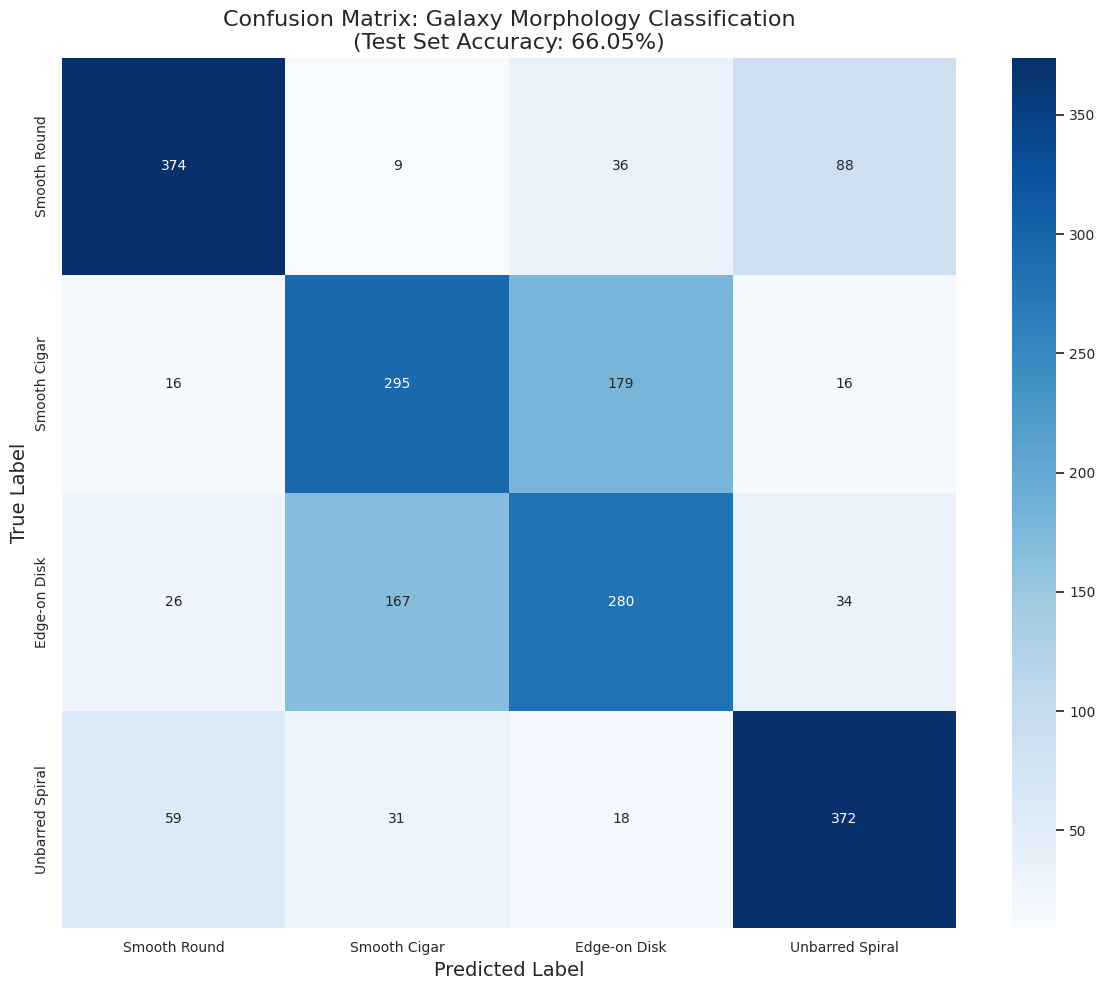

In [48]:
# TODO: Plot confusion matrix
# Generate confusion matrix
# Note: 'target' and 'preds' are already defined in the previous cell from the test loop
cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title(f'Confusion Matrix: Galaxy Morphology Classification\n(Test Set Accuracy: {test_accuracy:.2%})', fontsize=16)
plt.show()

### 7. Interactive Galaxy Explorer GUI

This interactive visualization tool allows you to browse through the validation set and examine the 
model's predictions in real-time. The GUI displays each galaxy image using the Magma colormap 
(commonly used in astronomy visualization) alongside the model's softmax probability distribution
across all four classes.

Controls
--------
- **LEFT/RIGHT Arrow Keys:** Navigate through validation samples
- **R Key:** Jump to a random sample
- **M Key:** Toggle Magma colormap on/off
- **Q Key:** Quit the application

The visualization highlights the predicted class with a green bar, making it easy to spot correct 
classifications and identify failure cases where the model might confuse similar morphologies 
(e.g., smooth round vs. smooth cigar galaxies).

Assuming `pygame` is installed, if not, you can install it by creating a new code cell in your Jupyter notebook and running:
```bash
%pip install pygame
```

In [21]:
from model.gui import GalaxyExplorerGUI

In [22]:
# Ensure the model is in evaluation mode
model.eval()

# Instantiate the GUI
# x_val and y_val are the tensors we created from the GalaxyMNIST dataset
explorer = GalaxyExplorerGUI(
    model=model, 
    x_val=x_val, 
    y_val=y_val_onehot, 
    device=DEVICE
)
#explorer.run()

## 8. Export Model Weights for C/RISC-V Programs

Finally, we export the trained model parameters to files that can be loaded by C or RISC-V implementations. This enables deployment of the model on embedded systems or custom hardware accelerators without requiring a Python runtime.

The exporter utility serializes all weight matrices, biases, and S4 state space parameters to a format compatible with low-level implementations.

In [23]:
export_model_parameters(model, "model_params")

# Save for other python programs (e.g., GUI)
torch.save(model.state_dict(), f"model_params/galaxys4{'-colored' if COLORED else ''}-{RNG_SEED}.pth")

--- Exporting Model: GalaxyClassifierS4D ---
Saving: hilbert_scan.indices                     | Shape: [4096]
Saving: uproject.weight                          | Shape: [64, 1]
Saving: uproject.bias                            | Shape: [64]
Saving: s4_1.log_dt                              | Shape: [64]
Saving: s4_1.log_A_real                          | Shape: [64, 32]
Saving: s4_1.A_imag                              | Shape: [64, 32]
Saving: s4_1.C                                   | Shape: [64, 32, 2]
Saving: s4_1.D                                   | Shape: [64]
Saving: s4_2.log_dt                              | Shape: [64]
Saving: s4_2.log_A_real                          | Shape: [64, 32]
Saving: s4_2.A_imag                              | Shape: [64, 32]
Saving: s4_2.C                                   | Shape: [64, 32, 2]
Saving: s4_2.D                                   | Shape: [64]
Saving: fc.weight                                | Shape: [4, 64]
Saving: fc.bias                    

In [42]:
# 1. Safely lower the learning rate of the CURRENT optimizer
# We do this directly here so we don't have to scroll up
for param_group in optimizer.param_groups:
    param_group['lr'] = 0.0005  # Lowering from 0.0015 to 0.0005 for safety

# 2. Set strict limit of 5 epochs
EPOCHS = 5

# 3. Resume training immediately
print("Starting fine-tuning for 5 final epochs...")
train_hist_final = train(train_loader, val_loader, model, optimizer, loss_fn, EPOCHS, DEVICE, verbose=True)

# 4. Save the results
history["loss"].extend(train_hist_final["loss"])
history["val_accuracy"].extend(train_hist_final["val_accuracy"])

print("DONE! Now run the Test Accuracy cell one last time.")

Starting fine-tuning for 5 final epochs...


Epoch 1/5 - Training: 100%|███████████████████████████████████████████████████████████████| 100/100 [04:50<00:00,  2.90s/it, Batch Loss=0.65]


Epoch 1/5 - Loss: 0.7117 - Val Accuracy: 0.6575


Epoch 2/5 - Training: 100%|██████████████████████████████████████████████████████████████| 100/100 [04:55<00:00,  2.96s/it, Batch Loss=0.766]


Epoch 2/5 - Loss: 0.7056 - Val Accuracy: 0.6525


...

Epoch 3/5 - Loss: 0.7034 - Val Accuracy: 0.6450


Epoch 4/5 - Training: 100%|██████████████████████████████████████████████████████████████| 100/100 [06:00<00:00,  3.61s/it, Batch Loss=0.792]


Epoch 4/5 - Loss: 0.7003 - Val Accuracy: 0.6506


Epoch 5/5 - Training: 100%|██████████████████████████████████████████████████████████████| 100/100 [05:37<00:00,  3.38s/it, Batch Loss=0.611]


Epoch 5/5 - Loss: 0.6943 - Val Accuracy: 0.6500
DONE! Now run the Test Accuracy cell one last time.


In [49]:
import torch
from torchinfo import summary
from model.gclassifier import GalaxyClassifierS4D

# 1. Initialize the model exactly as you trained it (Grayscale)
# s4_state=64, d_model=64 is the requirement
model_verify = GalaxyClassifierS4D(s4_state=64, d_model=64, num_classes=4, colored=False)

# 2. Run the summary
# Input size: (Batch_Size, Channels, Height, Width) -> (1, 1, 64, 64)
summary(model_verify, input_size=(1, 1, 64, 64))

Layer (type:depth-idx)                   Output Shape              Param #
GalaxyClassifierS4D                      [1, 4]                    --
├─HilbertScan: 1-1                       [1, 4096, 1]              --
├─Linear: 1-2                            [1, 4096, 64]             128
├─S4D: 1-3                               [1, 4096, 64]             8,320
├─GELU: 1-4                              [1, 4096, 64]             --
├─S4D: 1-5                               [1, 4096, 64]             8,320
├─GELU: 1-6                              [1, 4096, 64]             --
├─TakeLastTimestep: 1-7                  [1, 64]                   --
├─Linear: 1-8                            [1, 4]                    260
├─Softmax: 1-9                           [1, 4]                    --
Total params: 17,028
Trainable params: 17,028
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.02
Forward/backward pass size (MB): 6.29
Params size (MB): 0.07
Estimated Total Size (MB

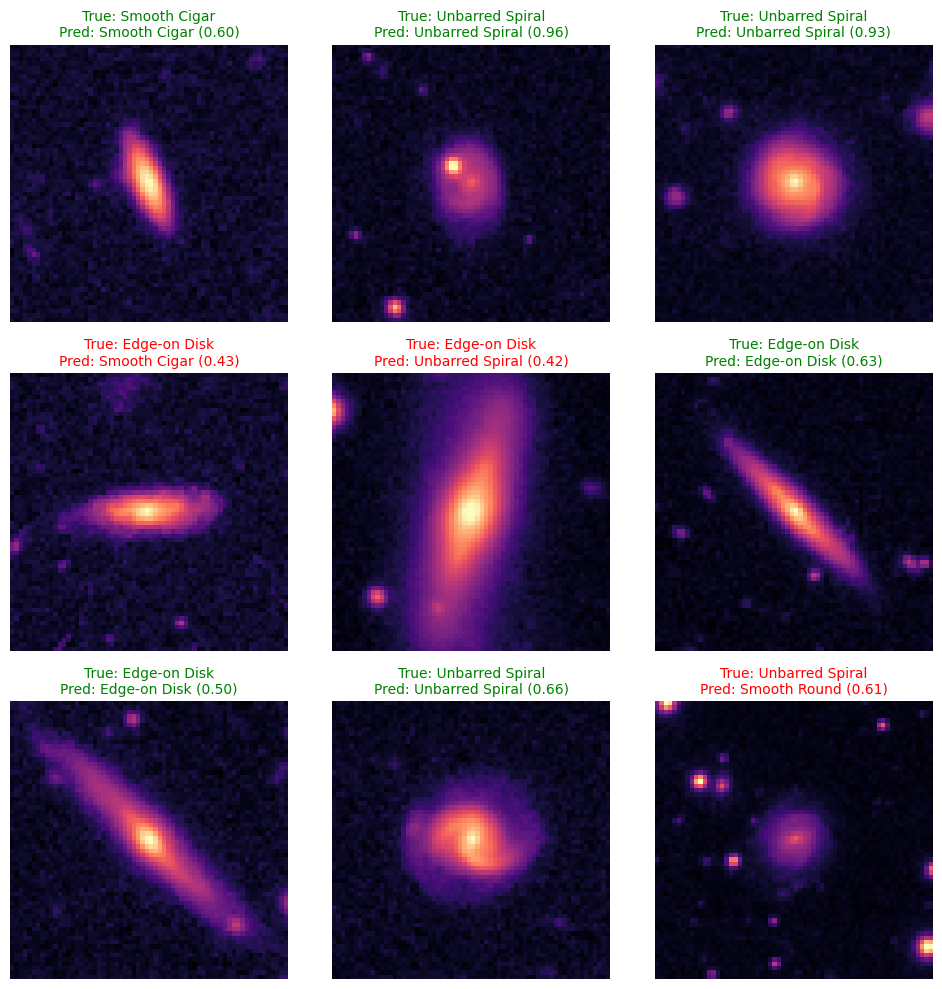

In [50]:
# --- Task 10.4: Sample Predictions Grid ---
import matplotlib.pyplot as plt
import numpy as np

def plot_sample_predictions(model, loader, device, num_samples=9):
    model.eval()
    samples = []
    
    # Get a batch
    imgs, labels = next(iter(loader))
    imgs, labels = imgs.to(device), labels.to(device)
    
    # Predict
    with torch.no_grad():
        logits = model(imgs, return_logits=True)
        probs = torch.nn.functional.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        targets = torch.argmax(labels, dim=1)
    
    # Select 9 random indices
    indices = np.random.choice(len(imgs), num_samples, replace=False)
    
    fig, axes = plt.subplots(3, 3, figsize=(10, 10))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        img = imgs[idx].cpu().squeeze().numpy()
        true_label = CLASS_NAMES[targets[idx].item()]
        pred_label = CLASS_NAMES[preds[idx].item()]
        conf = probs[idx][preds[idx]].item()
        
        # Color: Green if correct, Red if wrong
        color = 'green' if true_label == pred_label else 'red'
        
        axes[i].imshow(img, cmap='magma')
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label} ({conf:.2f})", 
                          color=color, fontsize=10)
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run it
plot_sample_predictions(model, test_loader, DEVICE)